# CT Injection Tampering Detection: U-Net++ with Soft-KNN Head

## Overview
This notebook trains a **U-Net++ segmentation model** with a **differentiable Soft-KNN head** for detecting tampered (injected) regions in CT scans. The model focuses on **injection-only data** from the dataset.

### Key Components:
- **Data**: CT slices with disk-shaped annotations for injection sites. Uses multi-channel windowing (Lung, Soft Tissue, Bone) + CLAHE enhancement.
- **Data Split**: Random slice-wise split (70% train, 30% val). **Patient-grouped batch sampling** ensures most batches are from the same patient to handle intra-patient correlations, filling with repeats if needed.
- **Augmentations**: Heavy for train (flips, elastic, dropout, photometric); light noise for val.
- **Model**: U-Net++ (ResNet-34 encoder) + Dropout + PixelFeatureHead for Soft-KNN.
- **Loss**: Combined Focal + Dice + Weighted Soft-KNN (for few-shot-like consistency).
- **Training**: AdamW → SGD switch, Cosine scheduler, AMP, Gradient accumulation.
- **Evaluation**: Dice, IoU metrics. Early stopping on val IoU.
- **Outputs**: Checkpoints, history JSON, plots, TensorBoard logs.

### Kaggle Adaptations:
- **Paths**: Input data from `/kaggle/input/capstone-main/` (assume dataset uploaded there with `CT_Injection/` subdir and `data_v1.csv`).
- **Outputs**: Saved to `/kaggle/working/` for checkpoints/logs/plots.
- **Installs**: Added `!pip` for missing libs (run once).
- **No Colab/Drive**: Removed `drive.mount`; uses Kaggle env.

### Data Saving & Metrics:
- **Saves**: Best/last checkpoints (model + feat_head), `history.json` (all epoch metrics), training curves PNG, sample viz PNG, test viz PNG.
- **Metrics Printed**: Per-epoch (train/val): Loss, Dice, IoU, LR. Final test on 100 unique patient slices.
- **TensorBoard**: Logs all metrics/LR. In Kaggle, run `%load_ext tensorboard` then `%tensorboard --logdir="/kaggle/working/logs/{exp_name}"` in a new cell.

### Data Split Explanation:
1. Load all injection slices from CSV (grouped by patient/slice).
2. **Slice-wise random split**: 70% train, 30% val (ignores patient overlap for simplicity; focuses on slice diversity).
3. **Patient Grouping**: For training, build dict of `patient_id → list of sample indices`. Batches sample primarily from one patient per batch, shuffling patients across batches.
4. **Batch Filling**: If a patient has < batch_size slices, repeat random ones to fill.
5. **Summary**: Prints #patients/#slices for splits (reversed order: Val first, then Train for emphasis on held-out data).

### Patient-Wise Batching:
- Custom `PatientGroupedBatchSampler`: Iterates over shuffled patients.
- For each patient: Shuffle their slices, yield batches of size `batch_size` (with repeats if short).
- Ensures model sees intra-patient consistency (e.g., similar anatomy) within batches, reducing variance.

### Model Details:
- **Backbone**: U-Net++ (nested decoders for better boundaries) with ResNet-34 encoder (ImageNet pre-trained).
- **Input**: 3-channel (windowed CT) → 256x256.
- **Output**: Binary logits (1= tampered/injected region).
- **Soft-KNN Head**: Extracts pixel features (from img + seg probs), samples balanced support pixels/batch, computes soft NN weights (beta=10 for sharpness), adds BCE loss for consistency.
- **Why Soft-KNN?**: Mimics few-shot learning; encourages local pixel similarity w.r.t. annotations.

Run cells sequentially. Training may take hours; resume from checkpoints.

In [ ]:
# Install dependencies (Kaggle-specific: run once)
!pip install -q segmentation_models_pytorch albumentations termcolor

# Imports
import os
import json
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import cv2
import time
from termcolor import colored
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler
from torch.optim import AdamW, SGD
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.cuda.amp import GradScaler, autocast
from torch.utils.tensorboard import SummaryWriter
from sklearn.model_selection import train_test_split
from skimage.morphology import remove_small_objects, label
from skimage.measure import regionprops
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from packaging import version
from collections import defaultdict
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# Set seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

## Configuration
Defines paths (Kaggle-adapted), model params, training hyperparameters, and Soft-KNN settings. Outputs go to `/kaggle/working/` for easy download.

In [ ]:
class CFG:
    # Paths (Kaggle: Input from /kaggle/input/, Outputs to /kaggle/working/)
    BASE_PATH = "/kaggle/input/capstone-main"  # Upload dataset here with CT_Injection subdir
    INJECTION_DIR = "CT_Injection"
    INJECTION_CSV = "data_v1.csv"
    OUTPUT_BASE = "/kaggle/working"  # For checkpoints, logs, plots
    
    # Model & Training Params
    encoder = "resnet34"
    img_size = 256
    radius_px = 32
    batch_size = 32  # Mostly from same patient
    accum_steps = 4
    num_workers = 2
    
    # Optimizer & Scheduler Params
    adam_epochs = 70
    sgd_epochs = 80
    max_lr = 1e-4
    base_lr = 3e-6
    weight_decay = 1e-4
    scheduler_T_0 = 10
    scheduler_eta_min = 1e-6
    
    # KNN-like (soft) head params
    knn_support_per_batch = 1024  # Support pixels sampled per batch
    knn_beta = 10.0  # Sharpness of NN weights
    knn_feat_channels = 16  # Feature dim
    knn_loss_weight = 1.0  # Weight in total loss
    knn_sample_balance = True  # Balance pos/neg supports
    
    # General
    patience = 25
    val_split = 0.30  # 30% validation
    test_split = 0.0  # No separate test; use val subsample
    
    # Output & Logging
    save_samples = 16
    experiment_name = "unetpp_v8_softknn_injection_only_v2004"
    ckpt_dir = os.path.join(OUTPUT_BASE, "checkpoints", experiment_name)
    log_dir = os.path.join(OUTPUT_BASE, "logs", experiment_name)

os.makedirs(CFG.ckpt_dir, exist_ok=True)
os.makedirs(CFG.log_dir, exist_ok=True)

## Custom Collate & Batch Sampler
- **Collate**: Stacks imgs/masks; keeps sample dicts as list (for viz).
- **PatientGroupedBatchSampler**: 
  - Groups samples by `patient_id`.
  - Shuffles patients; for each, shuffles slices and yields batches.
  - Fills short batches with random repeats from the patient.
  - `__len__`: Estimates total batches via ceil division.

In [ ]:
def custom_collate(batch):
    imgs = torch.stack([b[0] for b in batch])
    masks = torch.stack([b[1] for b in batch])
    samples = [b[2] for b in batch]  # List of dicts
    return imgs, masks, samples

class PatientGroupedBatchSampler(Sampler):
    def __init__(self, samples, patient_groups, batch_size, shuffle_patients=True, shuffle_within=True):
        self.samples = samples
        self.patient_groups = patient_groups  # pid -> list of samples
        self.patient_indices = {}  # pid -> list of indices in samples
        for pid in patient_groups:
            group_indices = [i for i, s in enumerate(samples) if s['patient_id'] == pid]
            self.patient_indices[pid] = group_indices
        self.pids = list(patient_groups.keys())
        self.batch_size = batch_size
        self.shuffle_patients = shuffle_patients
        self.shuffle_within = shuffle_within

    def __iter__(self):
        pids = self.pids[:]
        if self.shuffle_patients:
            random.shuffle(pids)
        for pid in pids:
            indices = self.patient_indices[pid][:]
            if self.shuffle_within:
                random.shuffle(indices)
            for start in range(0, len(indices), self.batch_size):
                batch = indices[start:start + self.batch_size]
                while len(batch) < self.batch_size and len(indices) > 0:
                    batch.append(random.choice(indices))  # Fill with repeat
                yield batch

    def __len__(self):
        total_batches = 0
        for indices in self.patient_indices.values():
            num_samples = len(indices)
            total_batches += (num_samples + self.batch_size - 1) // self.batch_size
        return total_batches

## Dataset & Transforms
### Preprocessing:
- **Windowing**: 3 channels (Lung: -600/1500, Soft: 40/400, Bone: 400/1800) → uint8.
- **CLAHE**: Contrast enhancement on Lung channel.
- **Masks**: Draw disks (r=32px) at annotation (x,y) points.

### Augmentations:
- **Train**: Resize, flips, shift/scale/rotate, elastic/grid distortion, coarse dropout, random photometric (brightness/contrast/equalize/unsharp/gauss noise), normalize.
- **Val**: Resize, light Gauss noise (σ=0.005, 50%), normalize.
- Albumentations version-aware (e.g., ElasticTransform params for v1.3+).

In [ ]:
def window_image(img, window_center, window_width, to_uint8=True):
    img_min = window_center - window_width // 2
    img_max = window_center + window_width // 2
    windowed_img = np.clip(img, img_min, img_max)
    normalized_img = (windowed_img - img_min) / (img_max - img_min + 1e-6)
    if to_uint8:
        return (normalized_img * 255).astype(np.uint8)
    return normalized_img

def get_transforms(is_train: bool, img_size: int):
    mean, std = (0.5, 0.5, 0.5), (0.5, 0.5, 0.5)
    alb_ver = version.parse(A.__version__)
    # ElasticTransform params (version-aware)
    elastic_kwargs = {"p": 0.4}
    if alb_ver >= version.parse("1.3.0"):
        elastic_kwargs.update({"alpha": 15, "sigma": 6, "alpha_affine": 10})
    # CoarseDropout params
    coarse_kwargs = {"p": 0.3}
    if alb_ver >= version.parse("1.3.0"):
        coarse_kwargs.update({
            "max_holes": 12, "min_holes": 2,
            "min_height": img_size // 30, "min_width": img_size // 30,
            "max_height": img_size // 15, "max_width": img_size // 15
        })
    if is_train:
        transforms = [
            A.Resize(img_size, img_size),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, rotate_limit=30, p=0.8),
            A.ElasticTransform(**elastic_kwargs),
            A.GridDistortion(p=0.3),
            A.CoarseDropout(**coarse_kwargs),
            # Random photometric (one per sample)
            A.OneOf([
                A.RandomBrightnessContrast(),
                A.Equalize(),
                A.UnsharpMask(),
                A.GaussNoise()
            ], p=0.7),
            A.Normalize(mean=mean, std=std),
            ToTensorV2(),
        ]
    else:
        transforms = [
            A.Resize(img_size, img_size),
            A.GaussNoise(var_limit=(0.0, 0.005**2), mean=0, p=0.5),  # Light noise
            A.Normalize(mean=mean, std=std),
            ToTensorV2(),
        ]
    return A.Compose(transforms)

def draw_disk(mask, cx, cy, r):
    H, W = mask.shape
    y, x = np.ogrid[:H, :W]
    dist2 = (x - cx) ** 2 + (y - cy) ** 2
    mask[dist2 <= r * r] = 1

def apply_clahe(img, clip_limit=2.0, tile_grid_size=(8, 8)):
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    return clahe.apply(img)

class SegDataset(Dataset):
    def __init__(self, samples, img_size, is_train, radius_px):
        self.samples = samples
        self.radius_px = radius_px
        self.transforms = get_transforms(is_train, img_size)

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        img_raw = np.load(s['fpath']).astype(np.float32)
        # Multi-channel windowing
        ch1 = window_image(img_raw, -600, 1500, True)  # Lung
        ch2 = window_image(img_raw, 40, 400, True)    # Soft tissue
        ch3 = window_image(img_raw, 400, 1800, True)  # Bone
        ch1 = apply_clahe(ch1)  # Enhance primary channel
        img = np.stack([ch1, ch2, ch3], axis=-1)
        H, W = img.shape[:2]
        mask = np.zeros((H, W), dtype=np.uint8)
        for x, y in s.get('annotations', []):
            if x is not None and y is not None:
                cx, cy = int(np.clip(x, 0, W - 1)), int(np.clip(y, 0, H - 1))
                draw_disk(mask, cx, cy, self.radius_px)
        augmented = self.transforms(image=img, mask=mask)
        out_img = augmented['image'].float()
        out_mask = augmented['mask'].unsqueeze(0).float()
        return out_img, out_mask, s  # Sample dict for viz

## Dataloaders & Dataset Building
### Building Samples:
- Reads CSV, groups by (path, cur_slice).
- For each group: Loads .npy path, collects (x,y) annotations → sample dict with `patient_id = f"inj_{patient_rel}"`, `slice_id`.

### Split & Loaders:
- **Split**: `train_test_split` on slices (random, stratified=False; 70/30).
- **Train Loader**: Uses `PatientGroupedBatchSampler` for patient-grouped batches + custom collate.
- **Val Loader**: Standard shuffle=False.
- Saves one augmented sample viz.

### Summary (Reversed Labels):
- Prints Val first (yellow), then Train (green) for emphasis on held-out set.

In [ ]:
def build_tamper_samples(root_dir, csv_path, dataset_label):
    df = pd.read_csv(csv_path)
    groups = df.groupby(["path", "cur_slice"])
    samples = []
    for (patient_rel, slice_id), g in groups:
        fpath = os.path.join(root_dir, str(patient_rel), f"{int(slice_id)}.npy")
        if not os.path.exists(fpath): continue
        ann = [(int(r["x"]), int(r["y"])) for _, r in g.iterrows() if pd.notna(r["x"])]
        samples.append({"fpath": fpath, "patient_id": f"inj_{patient_rel}", "annotations": ann, "dataset": dataset_label, "slice_id": int(slice_id)})
    return samples

def visualize_sample(dataset, save_path):
    img, mask, _ = dataset[0]
    img_np = img.permute(1, 2, 0).numpy()
    mask_np = mask.squeeze(0).numpy()
    mean, std = np.array([0.5,0.5,0.5]), np.array([0.5,0.5,0.5])
    img_np = np.clip(img_np * std + mean, 0, 1)
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img_np)
    axes[0].set_title("Augmented Image")
    axes[0].axis('off')
    axes[1].imshow(mask_np, cmap='gray')
    axes[1].set_title("Augmented Mask")
    axes[1].axis('off')
    plt.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"✅ Saved augmented sample viz to {save_path}")

def get_dataloaders(cfg):
    inj_samples = build_tamper_samples(os.path.join(cfg.BASE_PATH, cfg.INJECTION_DIR), os.path.join(cfg.BASE_PATH, cfg.INJECTION_DIR, cfg.INJECTION_CSV), "injection")
    all_samples = inj_samples
    print(f"Found {len(inj_samples)} injection slices.")
    # Slice-wise split
    train_samples, val_samples = train_test_split(all_samples, test_size=cfg.val_split, random_state=42, shuffle=True)
    # Patient groups for train sampler
    train_patient_groups = defaultdict(list)
    for s in train_samples:
        train_patient_groups[s['patient_id']].append(s)
    train_ds = SegDataset(train_samples, cfg.img_size, True, cfg.radius_px)
    val_ds = SegDataset(val_samples, cfg.img_size, False, cfg.radius_px)
    visualize_sample(train_ds, os.path.join(cfg.ckpt_dir, "augmented_sample.png"))
    # Custom sampler for train
    train_batch_sampler = PatientGroupedBatchSampler(train_samples, train_patient_groups, cfg.batch_size, shuffle_patients=True, shuffle_within=True)
    train_loader = DataLoader(train_ds, batch_sampler=train_batch_sampler, num_workers=cfg.num_workers, pin_memory=True, collate_fn=custom_collate)
    val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=True, collate_fn=custom_collate)
    print(f"Train: {len(train_samples)} samples ({len(train_patient_groups)} patients), Val: {len(val_samples)} samples.")
    return train_loader, val_loader, val_samples, train_samples

def summarize_dataset_splits(train_samples, val_samples):
    def summarize(samples):
        patient_ids = {s['patient_id'] for s in samples}
        total_slices = len(samples)
        return len(patient_ids), total_slices
    train_p, train_s = summarize(train_samples)
    val_p, val_s = summarize(val_samples)
    print("\n" + "=" * 60)
    print(colored("📊 DATA SPLIT SUMMARY (Reversed: Val first)", "cyan", attrs=["bold"]))
    print("=" * 60)
    print(colored(f"VAL ➜ {val_p} patients | {val_s} slices", "yellow"))  # Reversed: Val first
    print(colored(f"TRAIN ➜ {train_p} patients | {train_s} slices", "green"))
    print("=" * 60 + "\n")

## Losses & Metrics
- **CombinedLoss**: 0.5 * Focal (binary) + 0.5 * Dice (from_logits=True).
- **Metrics**: Per-batch Dice/IoU (flat, mean over batch). Epsilon=1e-6 for stability.

In [ ]:
class CombinedLoss(nn.Module):
    def __init__(self, w_focal=0.5, w_dice=0.5):
        super().__init__()
        self.focal_loss = smp.losses.FocalLoss(mode='binary')
        self.dice_loss = smp.losses.DiceLoss(mode='binary', from_logits=True)
        self.w_focal = w_focal
        self.w_dice = w_dice

    def forward(self, logits, targets):
        focal = self.focal_loss(logits, targets)
        dice = self.dice_loss(logits, targets)
        return self.w_focal * focal + self.w_dice * dice

@torch.no_grad()
def compute_metrics(preds, targets):
    preds_flat = preds.view(preds.shape[0], -1)
    targets_flat = targets.view(targets.shape[0], -1)
    tp = (preds_flat & targets_flat).sum(dim=1)
    fp = (preds_flat & ~targets_flat).sum(dim=1)
    fn = (~preds_flat & targets_flat).sum(dim=1)
    epsilon = 1e-6
    dice = (2. * tp + epsilon) / (2. * tp + fp + fn + epsilon)
    iou = (tp + epsilon) / (tp + fp + fn + epsilon)
    return dice.mean().item(), iou.mean().item()

## Soft-KNN Head & Predictor
### PixelFeatureHead:
- CNN: ConvBNReLU x2 → 1x1 Conv to `knn_feat_channels=16`.
- Input: [B,4,H,W] (RGB + seg probs).

### SoftKNN:
- **Predict**: Computes Euclidean dists (chunked for memory: max 200MB chunks).
- Softmax(-beta * dist) → weighted avg of support labels → probs [0,1].
- Beta=10: Sharp NN approximation.

### Sampling Supports:
- Flatten feats/masks → sample up to 1024 pixels/batch (balanced pos/neg if possible; random otherwise).

In [ ]:
class PixelFeatureHead(nn.Module):
    def __init__(self, in_ch=4, out_ch=CFG.knn_feat_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, out_ch, 1)
        )

    def forward(self, x):
        return self.net(x)  # [B, C, H, W]

class SoftKNN:
    def __init__(self, beta=10.0, device='cpu'):
        self.beta = beta
        self.device = device

    def predict(self, support_feats, support_labels, query_feats):
        support_feats = support_feats.to(self.device)
        support_labels = support_labels.to(self.device)
        query_feats = query_feats.to(self.device)
        Ns = support_feats.shape[0]
        Nq = query_feats.shape[0]
        if Ns == 0 or Nq == 0:
            return torch.zeros((Nq,), device=self.device, dtype=query_feats.dtype)
        s2 = (support_feats ** 2).sum(dim=1, keepdim=True).t()  # (1, Ns)
        elem_size = query_feats.element_size()
        target_bytes = 200 * 1024 ** 2
        max_chunk = max(1, int(target_bytes // (max(1, Ns) * elem_size)))
        probs_chunks = []
        start = 0
        while start < Nq:
            end = min(Nq, start + max_chunk)
            q_chunk = query_feats[start:end]  # (chunk, C)
            q2 = (q_chunk ** 2).sum(dim=1, keepdim=True)  # (chunk,1)
            cross = q_chunk @ support_feats.t()
            dists = q2 + s2 - 2.0 * cross
            weights = F.softmax(-self.beta * dists, dim=1)  # (chunk, Ns)
            supp_lbl = support_labels.unsqueeze(0).float()  # (1, Ns)
            probs_chunk = (weights * supp_lbl).sum(dim=1)  # (chunk,)
            probs_chunks.append(probs_chunk)
            start = end
        probs = torch.cat(probs_chunks, dim=0)  # (Nq,)
        return probs

def sample_support_pixels(features, masks, max_support=2048, balance=True):
    B, C, H, W = features.shape
    device = features.device
    feats_flat = features.permute(0,2,3,1).reshape(-1, C)  # (B*H*W, C)
    masks_flat = masks.view(-1)  # (B*H*W,)
    pos_idx = (masks_flat > 0.5).nonzero(as_tuple=False).squeeze(1)
    neg_idx = (masks_flat <= 0.5).nonzero(as_tuple=False).squeeze(1)
    Ns = min(max_support, feats_flat.shape[0])
    if Ns == 0:
        return torch.empty((0, C), device=device), torch.empty((0,), device=device)
    if balance:
        half = Ns // 2
        chosen_idx = None
        if pos_idx.numel() > 0 and neg_idx.numel() > 0:
            pos_choose = pos_idx[torch.randperm(len(pos_idx))[:min(half, len(pos_idx))]]
            neg_choose = neg_idx[torch.randperm(len(neg_idx))[:min(Ns - len(pos_choose), len(neg_idx))]]
            chosen_idx = torch.cat([pos_choose, neg_choose])
            if len(chosen_idx) < Ns:
                remain = torch.randperm(feats_flat.shape[0])[:Ns - len(chosen_idx)]
                chosen_idx = torch.cat([chosen_idx, remain.to(device)])
        else:
            chosen_idx = torch.randperm(feats_flat.shape[0])[:Ns].to(device)
    else:
        chosen_idx = torch.randperm(feats_flat.shape[0])[:Ns].to(device)
    if chosen_idx.device != device:
        chosen_idx = chosen_idx.to(device)
    support_feats = feats_flat[chosen_idx]  # (Ns, C)
    support_labels = masks_flat[chosen_idx].float()
    return support_feats, support_labels

## Training & Validation Loops
### Train Epoch:
- Forward: Model logits → seg_loss.
- Feats: Cat(img, sigmoid(logits)) → feat_head → sample supports → per-batch SoftKNN BCE (chunked over B).
- Total loss: (seg + w*knn) / accum_steps → backward/scale/step.
- Metrics: Running avg loss/dice/iou; tqdm postfix.

### Val Epoch:
- Similar, but no_grad, no optimizer; full batch loss (no accum).
- Prints all metrics.

In [ ]:
def train_one_epoch(model, train_loader, optimizer, loss_fn, scaler, device, cfg, feat_head, knn):
    model.train()
    feat_head.train()
    total_loss, total_dice, total_iou = 0.0, 0.0, 0.0
    pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc="Train")
    for i, (imgs, masks, _) in pbar:  # Ignore samples
        imgs, masks = imgs.to(device), masks.to(device)
        with autocast(dtype=torch.float16):
            logits = model(imgs)
            seg_loss = loss_fn(logits, masks)
            probs = torch.sigmoid(logits)  # [B,1,H,W]
            feat_input = torch.cat([imgs, probs], dim=1)  # [B, 4, H, W]
            pixel_feats = feat_head(feat_input)  # [B, C, H, W]
            support_feats, support_labels = sample_support_pixels(pixel_feats, masks, max_support=cfg.knn_support_per_batch, balance=cfg.knn_sample_balance)
            knn_loss_val = torch.tensor(0.0, device=device)
            if support_feats.shape[0] > 0:
                Bf, Cf, Hf, Wf = pixel_feats.shape
                knn_loss_acc = torch.tensor(0.0, device=device, dtype=torch.float32)
                for b in range(Bf):
                    query_feats = pixel_feats[b].permute(1, 2, 0).reshape(-1, Cf)  # (H*W, C)
                    soft_probs = knn.predict(support_feats, support_labels, query_feats)  # (H*W,)
                    soft_probs = soft_probs.clamp(1e-7, 1.0 - 1e-7).float()
                    soft_probs_map = soft_probs.view(1, 1, Hf, Wf)  # [1,1,H,W]
                    with autocast(enabled=False):
                        knn_loss_acc += F.binary_cross_entropy(soft_probs_map, masks[b:b+1].float(), reduction='mean')
                knn_loss_val = knn_loss_acc / float(Bf)
        total_batch_loss = seg_loss.to(torch.float32) + cfg.knn_loss_weight * knn_loss_val
        total_batch_loss = total_batch_loss / cfg.accum_steps
        scaler.scale(total_batch_loss).backward()
        if (i + 1) % cfg.accum_steps == 0 or (i + 1) == len(train_loader):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
        with torch.no_grad():
            preds = (torch.sigmoid(logits) > 0.5)
            d, iou_metric = compute_metrics(preds, masks.bool())
            total_dice += d
            total_iou += iou_metric
            total_loss += (total_batch_loss.item() * cfg.accum_steps)
        pbar.set_postfix(
            loss=f"{total_loss / (i + 1):.4f}",
            dice=f"{total_dice / (i + 1):.4f}",
            iou=f"{total_iou / (i + 1):.4f}",
            lr=f"{optimizer.param_groups[0]['lr']:.2e}"
        )
    return {
        "loss": total_loss / len(train_loader),
        "dice": total_dice / len(train_loader),
        "iou": total_iou / len(train_loader)
    }

@torch.no_grad()
def validate_one_epoch(model, loader, loss_fn, device, feat_head, knn, cfg):
    model.eval()
    feat_head.eval()
    total_loss, total_dice, total_iou = 0.0, 0.0, 0.0
    pbar = tqdm(loader, total=len(loader), desc="Validate")
    for imgs, masks, _ in pbar:  # Ignore samples
        imgs, masks = imgs.to(device), masks.to(device)
        with autocast(dtype=torch.float16):
            logits = model(imgs)
            loss = loss_fn(logits, masks)
            probs = torch.sigmoid(logits)
            feat_input = torch.cat([imgs, probs], dim=1)
            pixel_feats = feat_head(feat_input)
            support_feats, support_labels = sample_support_pixels(pixel_feats, masks, max_support=cfg.knn_support_per_batch, balance=cfg.knn_sample_balance)
            knn_loss_val = torch.tensor(0.0, device=device)
            if support_feats.shape[0] > 0:
                Bf, Cf, Hf, Wf = pixel_feats.shape
                knn_loss_acc = torch.tensor(0.0, device=device, dtype=torch.float32)
                for b in range(Bf):
                    query_feats = pixel_feats[b].permute(1, 2, 0).reshape(-1, Cf)
                    soft_probs = knn.predict(support_feats, support_labels, query_feats)
                    soft_probs = soft_probs.clamp(1e-7, 1.0 - 1e-7).float()
                    soft_probs_map = soft_probs.view(1, 1, Hf, Wf)
                    with autocast(enabled=False):
                        knn_loss_acc += F.binary_cross_entropy(soft_probs_map, masks[b:b+1].float(), reduction='mean')
                knn_loss_val = knn_loss_acc / float(Bf)
        total_loss += (loss.to(torch.float32) + cfg.knn_loss_weight * knn_loss_val).item()
        preds = torch.sigmoid(logits) > 0.5
        d, iou_metric = compute_metrics(preds, masks.bool())
        total_dice += d
        total_iou += iou_metric
        pbar.set_postfix(
            loss=f"{total_loss / (pbar.n + 1):.4f}",
            dice=f"{total_dice / (pbar.n + 1):.4f}",
            iou=f"{total_iou / (pbar.n + 1):.4f}"
        )
    return {
        "loss": total_loss / len(loader),
        "dice": total_dice / len(loader),
        "iou": total_iou / len(loader)
    }

## Training Manager
- **Optimizers**: AdamW (epochs 0-69, lr=1e-4) → SGD (70+, lr=3e-6, momentum=0.9, nesterov).
- **Scheduler**: CosineAnnealingWarmRestarts (T0=10, eta_min=1e-6); resets on switch.
- **Resume**: Loads from `last_checkpoint.pth` (model, feat_head, opt, sched, history, best_iou).
- **Logging**: TensorBoard (loss/dice/iou/LR per split); tqdm per epoch.
- **Saving**: Best (on val IoU) → separate PTHs; Last → full checkpoint; `history.json`.
- **Early Stop**: Patience=25 on val IoU.

In [ ]:
def train_model(model, train_loader, val_loader, device, cfg):
    model.to(device)
    loss_fn = CombinedLoss()
    scaler = GradScaler()
    writer = SummaryWriter(log_dir=cfg.log_dir)  # TensorBoard logs
    feat_head = PixelFeatureHead(in_ch=4, out_ch=cfg.knn_feat_channels).to(device)
    knn = SoftKNN(beta=cfg.knn_beta, device=device)
    optimizer_adam = AdamW(list(model.parameters()) + list(feat_head.parameters()), lr=cfg.max_lr, weight_decay=cfg.weight_decay)
    optimizer_sgd = SGD(list(model.parameters()) + list(feat_head.parameters()), lr=CFG.base_lr, momentum=0.9, weight_decay=CFG.weight_decay, nesterov=True)
    scheduler = CosineAnnealingWarmRestarts(optimizer_adam, T_0=cfg.scheduler_T_0, eta_min=cfg.scheduler_eta_min)
    start_epoch = 0
    best_iou = 0.0
    no_improve_epochs = 0
    history = []
    checkpoint_path = os.path.join(cfg.ckpt_dir, "last_checkpoint.pth")
    if os.path.exists(checkpoint_path):
        print(f"Resuming from {checkpoint_path}")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        feat_head.load_state_dict(checkpoint['feat_head_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_iou = checkpoint.get('best_iou', 0.0)
        history = checkpoint.get('history', [])
        if start_epoch < cfg.adam_epochs:
            optimizer_adam.load_state_dict(checkpoint['optimizer_state_dict'])
            print("Loaded AdamW state.")
        else:
            optimizer_sgd.load_state_dict(checkpoint['optimizer_state_dict'])
            print("Loaded SGD state.")
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        print(f"Resuming epoch {start_epoch}. Best IoU: {best_iou:.4f}")
    total_epochs = cfg.adam_epochs + cfg.sgd_epochs
    for epoch in range(start_epoch, total_epochs):
        epoch_start_time = time.time()
        if epoch < cfg.adam_epochs:
            current_optimizer = optimizer_adam
            if epoch == 0:
                print(f"--- AdamW Phase (0-{cfg.adam_epochs-1}) ---")
        else:
            if epoch == cfg.adam_epochs:
                print(f"--- Switching to SGD ( {cfg.adam_epochs}-{total_epochs-1} ) ---")
                scheduler = CosineAnnealingWarmRestarts(optimizer_sgd, T_0=cfg.scheduler_T_0, eta_min=cfg.scheduler_eta_min)
            current_optimizer = optimizer_sgd
        print(f"\nEpoch {epoch+1}/{total_epochs}")
        train_metrics = train_one_epoch(model, train_loader, current_optimizer, loss_fn, scaler, device, cfg, feat_head, knn)
        val_metrics = validate_one_epoch(model, val_loader, loss_fn, device, feat_head, knn, cfg)
        scheduler.step()
        # TensorBoard
        writer.add_scalar("Loss/train", train_metrics['loss'], epoch)
        writer.add_scalar("IoU/train", train_metrics['iou'], epoch)
        writer.add_scalar("Dice/train", train_metrics['dice'], epoch)
        writer.add_scalar("Loss/val", val_metrics['loss'], epoch)
        writer.add_scalar("IoU/val", val_metrics['iou'], epoch)
        writer.add_scalar("Dice/val", val_metrics['dice'], epoch)
        writer.add_scalar("LearningRate", current_optimizer.param_groups[0]['lr'], epoch)
        epoch_history = {
            "epoch": epoch + 1,
            "train_loss": train_metrics['loss'], "train_iou": train_metrics['iou'], "train_dice": train_metrics['dice'],
            "val_loss": val_metrics['loss'], "val_iou": val_metrics['iou'], "val_dice": val_metrics['dice']
        }
        history.append(epoch_history)
        epoch_duration = time.time() - epoch_start_time
        print(f"Epoch {epoch+1} done in {epoch_duration:.2f}s. Val IoU: {val_metrics['iou']:.4f}")
        is_best = val_metrics['iou'] > best_iou
        if is_best:
            best_iou = val_metrics['iou']
            no_improve_epochs = 0
            torch.save(model.state_dict(), os.path.join(cfg.ckpt_dir, "best_model.pth"))
            torch.save(feat_head.state_dict(), os.path.join(cfg.ckpt_dir, "best_feat_head.pth"))
            print(f"🚀 New best IoU: {best_iou:.4f}! Saved.")
        else:
            no_improve_epochs += 1
        # Save checkpoint
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'feat_head_state_dict': feat_head.state_dict(),
            'optimizer_state_dict': current_optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_iou': best_iou,
            'history': history
        }, checkpoint_path)
        if no_improve_epochs >= cfg.patience:
            print(f"Early stop after {cfg.patience} epochs no improve.")
            break
    writer.close()
    print("✅ Training complete.")
    with open(os.path.join(cfg.ckpt_dir, "history.json"), "w") as f:
        json.dump(history, f, indent=2)
    return model, feat_head

class UNetPlusPlus_Dropout(nn.Module):
    def __init__(self, encoder_name="resnet34", encoder_weights="imagenet", in_channels=3, classes=1, dropout=0.3):
        super().__init__()
        self.model = smp.UnetPlusPlus(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=in_channels,
            classes=classes
        )
        self.dropout = nn.Dropout2d(dropout)

    def forward(self, x):
        x = self.model(x)
        return self.dropout(x)

## Testing & Visualization
### Test:
- Sample 100 unique patients from val → random slice each → test_metrics (all: loss/dice/iou printed).

### Plots:
- **Curves**: Loss/Dice/IoU (train/val) from history.json → PNG save + show.

### Viz:
- 10 random test samples: Image | Overlay (red for pred tampered) → PNG save + show.

In [ ]:
@torch.no_grad()
def test_and_visualize(model, feat_head, val_samples, device, cfg):
    # Sample 100 unique patient slices from val
    patient_groups = defaultdict(list)
    for s in val_samples:
        patient_groups[s['patient_id']].append(s)
    unique_pids = list(patient_groups.keys())
    num_to_sample = min(100, len(unique_pids))
    selected_pids = random.sample(unique_pids, num_to_sample)
    test_samples = [random.choice(patient_groups[pid]) for pid in selected_pids]
    test_ds = SegDataset(test_samples, cfg.img_size, False, cfg.radius_px)
    test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=True, collate_fn=custom_collate)
    loss_fn = CombinedLoss()
    knn = SoftKNN(beta=cfg.knn_beta, device=device)
    test_metrics = validate_one_epoch(model, test_loader, loss_fn, device, feat_head, knn, cfg)
    print(f"\nFinal Test Metrics (100 unique patients):")
    print(f"Loss: {test_metrics['loss']:.4f}, Dice: {test_metrics['dice']:.4f}, IoU: {test_metrics['iou']:.4f}")
    
    # Plot curves from history
    with open(os.path.join(cfg.ckpt_dir, "history.json"), "r") as f:
        history = json.load(f)
    epochs = [h['epoch'] for h in history]
    train_loss = [h['train_loss'] for h in history]
    val_loss = [h['val_loss'] for h in history]
    train_dice = [h['train_dice'] for h in history]
    val_dice = [h['val_dice'] for h in history]
    train_iou = [h['train_iou'] for h in history]
    val_iou = [h['val_iou'] for h in history]
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    axs[0].plot(epochs, train_loss, label='Train Loss')
    axs[0].plot(epochs, val_loss, label='Val Loss')
    axs[0].set_title('Loss Curves')
    axs[0].legend()
    axs[1].plot(epochs, train_dice, label='Train Dice')
    axs[1].plot(epochs, val_dice, label='Val Dice')
    axs[1].set_title('Dice Curves')
    axs[1].legend()
    axs[2].plot(epochs, train_iou, label='Train IoU')
    axs[2].plot(epochs, val_iou, label='Val IoU')
    axs[2].set_title('IoU Curves')
    axs[2].legend()
    plt.tight_layout()
    plot_path = os.path.join(cfg.ckpt_dir, "training_curves.png")
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Curves saved to {plot_path}")
    
    # Viz 10 samples
    viz_indices = random.sample(range(len(test_ds)), min(10, len(test_ds)))
    model.eval()
    feat_head.eval()
    fig, axs = plt.subplots(10, 2, figsize=(10, 50))
    for row, idx in enumerate(viz_indices):
        img, mask, s = test_ds[idx]
        img = img.unsqueeze(0).to(device)
        logits = model(img)
        pred = torch.sigmoid(logits) > 0.5
        pred_np = pred.squeeze().cpu().numpy()
        img_np = img.squeeze().permute(1, 2, 0).cpu().numpy()
        mean, std = np.array([0.5,0.5,0.5]), np.array([0.5,0.5,0.5])
        img_np = np.clip(img_np * std + mean, 0, 1)
        # Red overlay for pred
        overlay = img_np.copy()
        overlay[pred_np] = [1, 0, 0]
        axs[row, 0].imshow(img_np)
        axs[row, 0].set_title("Image")
        axs[row, 0].axis('off')
        axs[row, 1].imshow(overlay)
        axs[row, 1].set_title("Tampered Overlay")
        axs[row, 1].axis('off')
    plt.tight_layout()
    viz_path = os.path.join(cfg.ckpt_dir, "test_visualizations.png")
    plt.savefig(viz_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Viz saved to {viz_path}")

## Main Execution
- Device setup (CUDA if avail).
- Build dataloaders → summary (reversed).
- Instantiate model → sanity forward pass.
- **Train** (with Soft-KNN).
- **Test/Viz** on best model.
- Prints TensorBoard commands (run in new cell for Kaggle).

In [ ]:
# Main
if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")
    torch.cuda.empty_cache()
    
    train_loader, val_loader, val_samples, train_samples = get_dataloaders(CFG)
    summarize_dataset_splits(train_samples, val_samples)  # Reversed print
    
    model = UNetPlusPlus_Dropout(
        encoder_name=CFG.encoder,
        encoder_weights="imagenet",
        in_channels=3,
        classes=1,
        dropout=0.3
    ).to(device)
    
    # Sanity check
    try:
        test_input = torch.randn(2, 3, CFG.img_size, CFG.img_size, device=device)
        with autocast(dtype=torch.float16):
            output = model(test_input)
        print(f"✅ Model OK. Output shape: {output.shape}")
    except Exception as e:
        print(f"❌ Forward fail: {e}")
    
    # Train
    print("\n--- Training (Injection + Soft-KNN) ---")
    model, feat_head = train_model(model, train_loader, val_loader, device, CFG)
    
    # Test & Viz
    print("\n--- Final Test & Viz ---")
    model.load_state_dict(torch.load(os.path.join(CFG.ckpt_dir, "best_model.pth"), map_location=device))
    feat_head.load_state_dict(torch.load(os.path.join(CFG.ckpt_dir, "best_feat_head.pth"), map_location=device))
    test_and_visualize(model, feat_head, val_samples, device, CFG)
    
    print(f"\n✅ DONE! Check {CFG.ckpt_dir} for saves, {CFG.log_dir} for logs.")
    print("For TensorBoard (new cell):")
    print("%load_ext tensorboard")
    print(f"%tensorboard --logdir=\"{CFG.log_dir}\"")

🏆 Best Epoch Based on Highest val_dice:

 epoch  train_loss  train_iou  train_dice  val_loss  val_iou  val_dice
  61.0    0.145882   0.768718    0.839303  0.148007 0.740218  0.823852


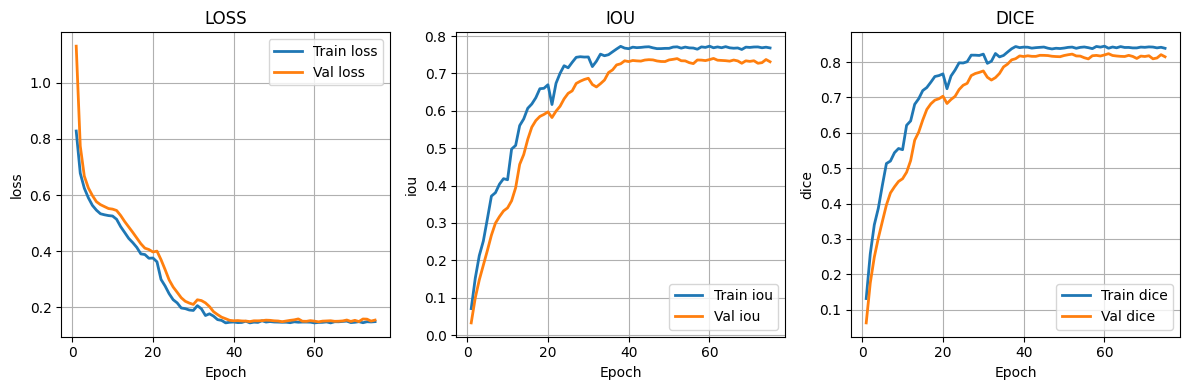

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# Path to your JSON file
path = "/content/drive/MyDrive/Capstone/main/checkpoints/unetpp_v8_softknn_injection_only_v2/history.json"

# Load JSON
with open(path, "r") as f:
    history = json.load(f)

# Ensure it's a list of epochs
if isinstance(history, dict):
    history = [history]

df = pd.DataFrame(history)

# Find best epoch based on highest val_dice
best_row = df.loc[df["val_dice"].idxmax()]

# Print only the best epoch data
print("🏆 Best Epoch Based on Highest val_dice:\n")
print(best_row.to_frame().T.to_string(index=False))

# Plot graphs (no points)
metrics = ["loss", "iou", "dice"]
plt.figure(figsize=(12, 4))

for i, metric in enumerate(metrics):
    plt.subplot(1, 3, i + 1)
    plt.plot(df["epoch"], df[f"train_{metric}"], label=f"Train {metric}", linewidth=2)
    plt.plot(df["epoch"], df[f"val_{metric}"], label=f"Val {metric}", linewidth=2)
    plt.title(metric.upper())
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()
